# OAT 2 — Baselines, validação temporal e features

Entrega consolidada da Sprint 2 da MecâniQA para a série `Trocas_Oleo`.

## Decisões da equipe

1. **Armadilha do futuro:** aplicar `shift(1)` antes da previsão e das janelas móveis.
2. **Estrutura:** funções simples e independentes, sem interfaces ou classes abstratas.
3. **MAE e RMSE:** MAE comunica o erro cotidiano; RMSE dá maior peso aos erros extremos.
4. **Validação:** usar `TimeSeriesSplit`, pois K-Fold pode treinar com datas futuras.
5. **Lags:** 1 dia (curto prazo), 7 dias (ciclo semanal) e 30 dias (referência mensal).
6. **NaNs:** descartar somente as linhas iniciais de aquecimento após criar as features.

## 1. Bibliotecas e carregamento

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    mean_squared_error, r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
data_path = next((c for c in [
    Path('data/mecaniqa_dataset.xlsx'),
    Path('../data/mecaniqa_dataset.xlsx'),
] if c.exists()), None)
if data_path is None:
    raise FileNotFoundError('Dataset não encontrado.')

dados_brutos = pd.read_excel(data_path)
dados_brutos['Data'] = pd.to_datetime(dados_brutos['Data'], errors='raise')
serie = (dados_brutos.sort_values('Data').set_index('Data')['Trocas_Oleo']
         .resample('D').sum(min_count=1))
serie.head()

Data
2024-01-01    11.0
2024-01-02     9.0
2024-01-03    12.0
2024-01-04    15.0
2024-01-05    25.0
Freq: D, Name: Trocas_Oleo, dtype: float64

## 2. Baselines sem vazamento temporal

In [3]:
def baseline_naive(serie_temporal):
    """Prevê t com o último valor conhecido até t-1."""
    return serie_temporal.ffill().shift(1).rename('Naive')


def baseline_media_movel(serie_temporal, janela=7):
    """Prevê t com a média dos valores conhecidos anteriores a t."""
    passado = serie_temporal.ffill().shift(1)
    return passado.rolling(janela, min_periods=janela).mean().rename(
        f'Média móvel ({janela} dias)'
    )


comparacao = pd.concat([
    serie.rename('Real'), baseline_naive(serie),
    baseline_media_movel(serie, janela=7),
] , axis=1)
comparacao.head(15)

,Real,Naive,Média móvel (7 dias)
Data,,,
2024-01-01,11.0,NaN,NaN
2024-01-02,9.0,11.0,NaN
2024-01-03,12.0,9.0,NaN
2024-01-04,15.0,12.0,NaN
2024-01-05,25.0,15.0,NaN
2024-01-06,25.0,25.0,NaN
2024-01-07,31.0,25.0,NaN
2024-01-08,13.0,31.0,18.285714
2024-01-09,10.0,13.0,18.571429


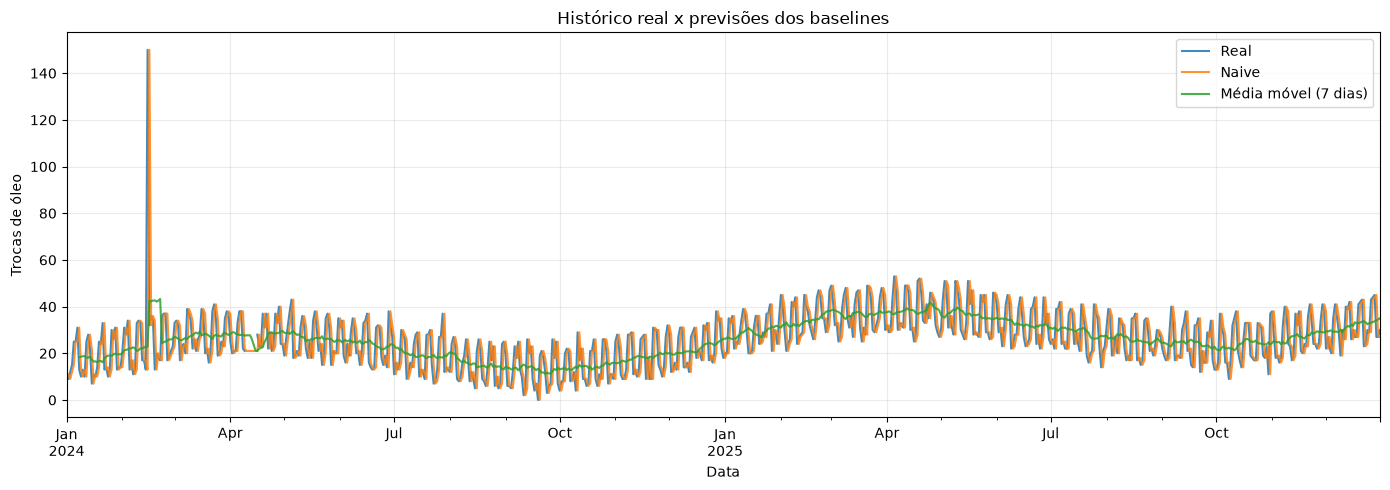

In [4]:
ax = comparacao.plot(figsize=(14, 5), alpha=0.85)
ax.set_title('Histórico real x previsões dos baselines')
ax.set_xlabel('Data')
ax.set_ylabel('Trocas de óleo')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Atestado do QA:** em `t`, o Naive usa `t-1`; a média móvel usa a janela encerrada em `t-1`. Nenhuma previsão acessa `t+1`.

## 3. TimeSeriesSplit e boletim

In [5]:
def calcular_metricas(real, previsto):
    pares = pd.concat([real.rename('real'), previsto.rename('previsto')], axis=1).dropna()
    sem_zero = pares['real'].ne(0)
    return {
        'MAE': mean_absolute_error(pares['real'], pares['previsto']),
        'RMSE': np.sqrt(mean_squared_error(pares['real'], pares['previsto'])),
        'MAPE': 100 * mean_absolute_percentage_error(
            pares.loc[sem_zero, 'real'], pares.loc[sem_zero, 'previsto']
        ) if sem_zero.any() else np.nan,
    }


def avaliar_baselines_temporais(serie_temporal, n_splits=5, janela=7):
    registros = []
    for fold, (_, teste) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(serie_temporal), 1):
        # Walk-forward: um real do teste só participa da previsão do dia seguinte.
        prefixo = serie_temporal.iloc[:teste[-1] + 1]
        previsoes = {
            'Naive': baseline_naive(prefixo).iloc[teste],
            f'Média móvel ({janela} dias)': baseline_media_movel(prefixo, janela).iloc[teste],
        }
        real = serie_temporal.iloc[teste]
        for modelo, previsto in previsoes.items():
            registros.append({'Fold': fold, 'Modelo': modelo, **calcular_metricas(real, previsto)})
    return pd.DataFrame(registros)


metricas_folds = avaliar_baselines_temporais(serie)
metricas_folds

,Fold,Modelo,MAE,RMSE,MAPE
0,1,Naive,6.867769,9.074986,42.549639
1,1,Média móvel (7 dias),7.402597,8.063084,47.786865
2,2,Naive,6.611570,9.074531,51.021833
3,2,Média móvel (7 dias),7.391972,8.037513,59.762993
4,3,Naive,6.371901,8.333444,18.954565
5,3,Média móvel (7 dias),7.059032,7.962056,20.811054
6,4,Naive,6.702479,9.027506,23.104419
7,4,Média móvel (7 dias),7.412043,8.090378,26.326589
8,5,Naive,6.677686,9.081814,27.582173
9,5,Média móvel (7 dias),7.513577,8.287648,31.403519


In [6]:
resumo_baselines = metricas_folds.groupby('Modelo')[['MAE', 'RMSE', 'MAPE']].mean()
for modelo, metricas in resumo_baselines.iterrows():
    print(modelo)
    print(
        f"Resultados do Baseline - MAE: {metricas['MAE']:.4f}, "
        f"RMSE: {metricas['RMSE']:.4f}, MAPE: {metricas['MAPE']:.2f}%"
    )
print(f"Melhor baseline pelo menor MAE: {resumo_baselines['MAE'].idxmin()}")

Média móvel (7 dias)
Resultados do Baseline - MAE: 7.3558, RMSE: 8.0881, MAPE: 37.22%
Naive
Resultados do Baseline - MAE: 6.6463, RMSE: 8.9185, MAPE: 32.64%
Melhor baseline pelo menor MAE: Naive


Nos resultados medidos pela equipe, o **Naive** obteve o menor MAE e foi adotado como baseline principal. A média móvel de 7 dias apresentou menor RMSE.

## 4. Feature engineering temporal

In [7]:
df = pd.DataFrame({'alvo': serie})
df['lag_1'] = df['alvo'].shift(1)
df['lag_7'] = df['alvo'].shift(7)
df['lag_30'] = df['alvo'].shift(30)
df['rolling_7'] = df['alvo'].shift(1).rolling(7, min_periods=7).mean()
df['rolling_30'] = df['alvo'].shift(1).rolling(30, min_periods=30).mean()
df['dia_semana'] = df.index.dayofweek
df['mes'] = df.index.month

features_temporais = ['lag_1', 'lag_7', 'lag_30', 'rolling_7', 'rolling_30']
linhas_antes = len(df)
df = df.dropna(subset=['alvo', *features_temporais])
print(f'Linhas removidas no aquecimento: {linhas_antes - len(df)}')
print(f'Nulos nas features temporais: {df[features_temporais].isna().sum().sum()}')
df.head(15)

Linhas removidas no aquecimento: 66
Nulos nas features temporais: 0


,alvo,lag_1,lag_7,lag_30,rolling_7,rolling_30,dia_semana,mes
Data,,,,,,,,
2024-01-31,14.0,14.0,10.0,11.0,19.571429,17.900000,2,1
2024-02-01,21.0,14.0,13.0,9.0,20.142857,18.000000,3,2
2024-02-02,31.0,21.0,30.0,12.0,21.285714,18.400000,4,2
2024-02-03,28.0,31.0,26.0,15.0,21.428571,19.033333,5,2
2024-02-04,34.0,28.0,31.0,25.0,21.714286,19.466667,6,2
2024-02-05,13.0,34.0,13.0,25.0,22.142857,19.766667,0,2
2024-02-06,17.0,13.0,14.0,31.0,22.142857,19.366667,1,2
2024-02-07,11.0,17.0,14.0,13.0,22.571429,18.900000,2,2
2024-02-08,13.0,11.0,21.0,10.0,22.142857,18.833333,3,2


## 5. Pipeline preditivo

In [8]:
X, y = df.drop(columns='alvo'), df['alvo']
ponto_corte = int(len(df) * 0.80)
X_train, X_test = X.iloc[:ponto_corte], X.iloc[ponto_corte:]
y_train, y_test = y.iloc[:ponto_corte], y.iloc[ponto_corte:]
assert X_train.index.max() < X_test.index.min()
print(f'Treino: {X_train.index.min().date()} a {X_train.index.max().date()}')
print(f'Teste: {X_test.index.min().date()} a {X_test.index.max().date()}')

Treino: 2024-01-31 a 2025-08-20
Teste: 2025-08-21 a 2025-12-31


In [9]:
pipeline_base = Pipeline([
    ('imputacao', SimpleImputer(strategy='median')),
    ('padronizacao', StandardScaler()),
    ('modelo', Ridge()),
])
busca = GridSearchCV(
    pipeline_base, {'modelo__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring='neg_mean_absolute_error', cv=TimeSeriesSplit(n_splits=5),
)
busca.fit(X_train, y_train)
pipeline = busca.best_estimator_
print(f"Melhor alpha: {busca.best_params_['modelo__alpha']}")

Melhor alpha: 10.0


MAE:  4.106
RMSE: 4.955
R²:   0.676


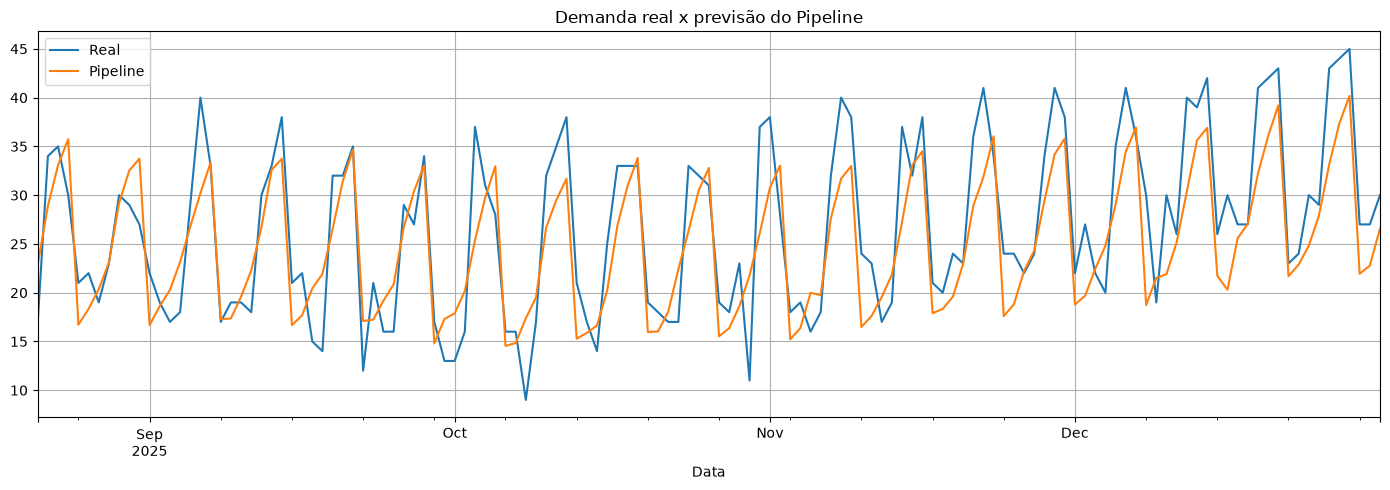

In [10]:
previsoes_pipeline = pipeline.predict(X_test)
print(f'MAE:  {mean_absolute_error(y_test, previsoes_pipeline):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, previsoes_pipeline)):.3f}')
print(f'R²:   {r2_score(y_test, previsoes_pipeline):.3f}')
resultado = pd.DataFrame({'Real': y_test, 'Pipeline': previsoes_pipeline}, index=y_test.index)
resultado.plot(figsize=(14, 5), title='Demanda real x previsão do Pipeline', grid=True)
plt.tight_layout()
plt.show()